First 5 Rows:
      video_id trending_date  \
0  kzwfHumJyYc      17.14.11   
1  zUZ1z7FwLc8      17.14.11   
2  10L1hZ9qa58      17.14.11   
3  N1vE8iiEg64      17.14.11   
4  kJzGH0PVQHQ      17.14.11   

                                               title    channel_title  \
0  Sharry Mann: Cute Munda ( Song Teaser) | Parmi...  Lokdhun Punjabi   
1  पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं...          HJ NEWS   
2  Stylish Star Allu Arjun @ ChaySam Wedding Rece...             TFPC   
3                     Eruma Saani | Tamil vs English      Eruma Saani   
4  why Samantha became EMOTIONAL @ Samantha naga ...       Filmylooks   

   category_id              publish_time  \
0            1  2017-11-12T12:20:39.000Z   
1           25  2017-11-13T05:43:56.000Z   
2           24  2017-11-12T15:48:08.000Z   
3           23  2017-11-12T07:08:48.000Z   
4           24  2017-11-13T01:14:16.000Z   

                                                tags    views  likes  \
0  sharry mann|"s

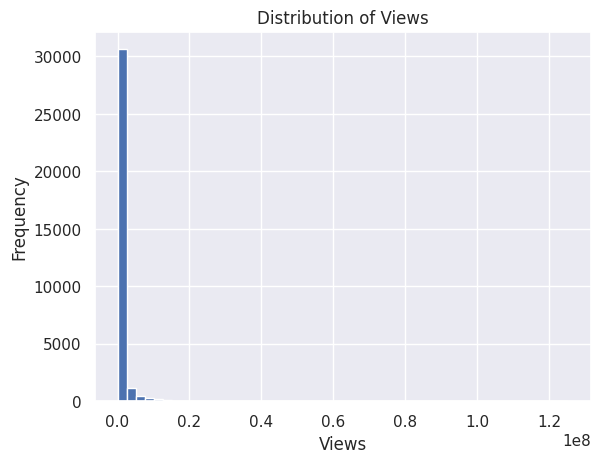

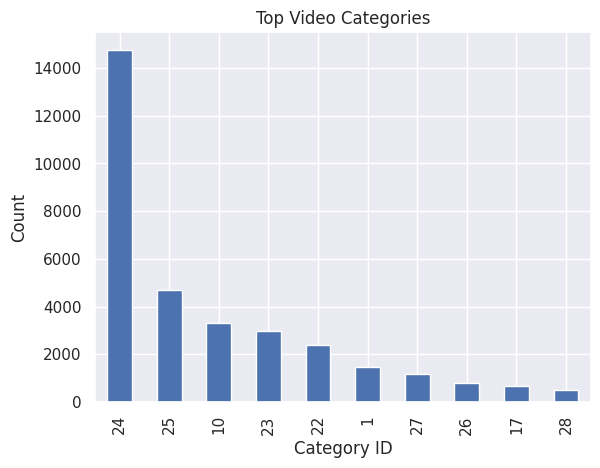

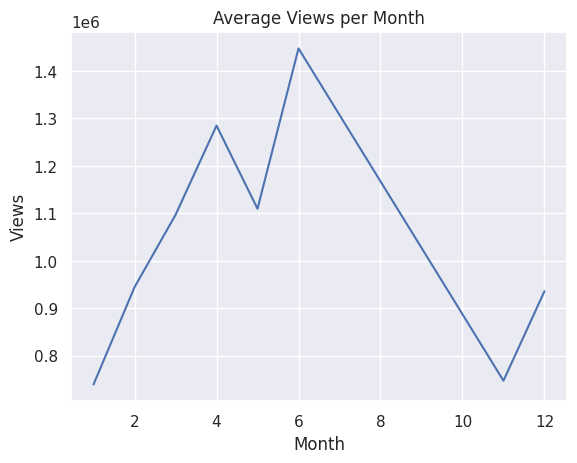

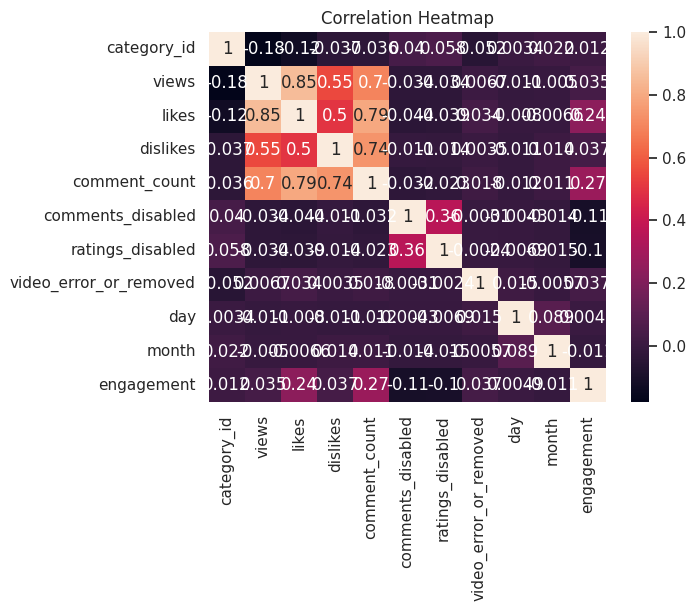

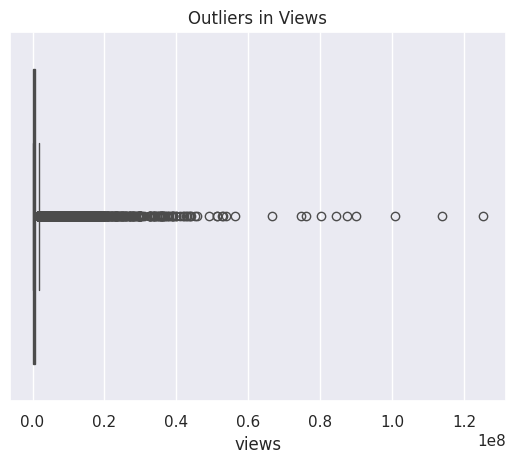


Final Missing Values:
video_id                  0
trending_date             0
title                     0
channel_title             0
category_id               0
publish_time              0
tags                      0
views                     0
likes                     0
dislikes                  0
comment_count             0
thumbnail_link            0
comments_disabled         0
ratings_disabled          0
video_error_or_removed    0
description               0
day                       0
month                     0
engagement                0
dtype: int64

Final Duplicate Count:
0

✅ Cleaned dataset saved successfully!


In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set()

data = pd.read_csv("INvideos.csv")

print("First 5 Rows:")
print(data.head())

print("\nDataset Info:")
print(data.info())

print("\nColumn Names:")
print(data.columns)

print("\nMissing Values Before Cleaning:")
print(data.isnull().sum())

for col in data.select_dtypes(include='object').columns:
    data[col] = data[col].fillna('Unknown')

for col in data.select_dtypes(include=['int64', 'float64']).columns:
    data[col] = data[col].fillna(data[col].median())

print("\nMissing Values After Cleaning:")
print(data.isnull().sum())

print("\nDuplicate Rows Before:", data.duplicated().sum())

data = data.drop_duplicates()

print("Duplicate Rows After:", data.duplicated().sum())

data['trending_date'] = pd.to_datetime(
    data['trending_date'], format='%y.%d.%m', errors='coerce'
)

data['publish_time'] = pd.to_datetime(data['publish_time'], errors='coerce')

print("\nData Types After Fixing:")
print(data.dtypes)

data.columns = data.columns.str.strip().str.lower()

for col in data.select_dtypes(include='object').columns:
    data[col] = data[col].str.lower().str.strip()

print("\nCleaned Column Names:")
print(data.columns)

data['day'] = data['trending_date'].dt.day
data['month'] = data['trending_date'].dt.month

data['engagement'] = (data['likes'] + data['comment_count']) / data['views']

print("\nNew Features Added: day, month, engagement")

print("\nTop 5 Most Viewed Videos:")
print(data.sort_values(by='views', ascending=False).head())

print("\nTop Categories:")
print(data['category_id'].value_counts().head())

plt.figure()
plt.hist(data['views'], bins=50)
plt.title("Distribution of Views")
plt.xlabel("Views")
plt.ylabel("Frequency")
plt.show()

plt.figure()
data['category_id'].value_counts().head(10).plot(kind='bar')
plt.title("Top Video Categories")
plt.xlabel("Category ID")
plt.ylabel("Count")
plt.show()

plt.figure()
data.groupby('month')['views'].mean().plot()
plt.title("Average Views per Month")
plt.xlabel("Month")
plt.ylabel("Views")
plt.show()

plt.figure()
sns.heatmap(data.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

plt.figure()
sns.boxplot(x=data['views'])
plt.title("Outliers in Views")
plt.show()

print("\nFinal Missing Values:")
print(data.isnull().sum())

print("\nFinal Duplicate Count:")
print(data.duplicated().sum())

data.to_csv("/content/cleaned_INvideos.csv", index=False)

print("\n✅ Cleaned dataset saved successfully!")
